# Part 2: Dynestyx — NumPyro with better support for dynamical systems
We introduce **dynestyx** as an extension of NumPyro for **dynamical systems**, with a clear separation between *what* the model is and *how* we simulate or score it.

## 2.1 Separation of concerns

**Dynestyx** extends NumPyro by giving you a standard way to work with dynamical systems. The key idea is **separation of concerns**:

- **What** the model is: parameters $\theta$, initial condition $p(x_0)$, state evolution (discrete or continuous time), observation model $p(y_t \mid x_t, \ldots)$. This is the `DynamicalModel`—you write it once as a generative model in code.
- **How** we simulate: *simulators* (e.g. `DiscreteTimeSimulator`, `SDESimulator`) unroll the dynamics step-by-step and generate state/observation trajectories. They interpret `dsx.sample("name", dynamics)` as "run the model forward in time."
- **How** we do inference: we can use either *simulators* (which sample latent states $x_{0:T}$ explicitly) or *filters* (which marginalize over them and compute $p(y_{1:T} \mid \theta)$). On top of that, we run standard NumPyro inference—**NUTS**, **SVI**, or others—to infer parameters (and optionally latent states when using a simulator).

You write the model once; then you choose how to interpret it (simulator vs. filter) and which inference algorithm to use.

## 2.2 A first Dynestyx model

For pedagogical purposes, we begin with a classic discrete-time linear-Gaussian system with controls. 

$$
\begin{aligned}
x_{t+1} &= Ax_t + Bu_t + \epsilon_t \\
y_t &= Cx_t + \eta_t
\end{aligned}
$$
with
$$
\begin{aligned}
x_0 &\sim \mathcal{N}(m_0, \ C_0) \\
\epsilon_t &\sim \mathcal{N}(0, \ \Sigma)  \\
\eta_t &\sim \mathcal{N}(0, \ \Gamma) 
\end{aligned}
$$

Written differently, we have:
$$
\begin{aligned}
\text{Initial Condition:} \quad x_0 &\sim \mathcal{N}(m_0, \ C_0) \\
\text{State-transition:} \quad x_{t+1} &\sim \mathcal{N}(Ax_t + Bu_t, \ \Sigma) \\
\text{Observation model:} \quad y_{t} &\sim \mathcal{N}(Cx_t, \ \Gamma) \\
\end{aligned}
$$

Furthermore, say we have prior belief about a subset of parameters in the model. Concretely, we will assume

$$
\begin{aligned}
A &= \begin{bmatrix} -1 & 0.3 \\ \rho & -0.2 \end{bmatrix} \\
B &= \begin{bmatrix} 1 \\ 0 \end{bmatrix} \\
C &= \begin{bmatrix} 1 & 0 \end{bmatrix} \\
\Sigma &= 0.1^2 I \\
\Gamma &= 0.1^2 I \\
m_0 &= 0\\
C_0 &= I
\end{aligned}
$$

and place a prior over the single unknown, $\rho$, in the system:

$$ \rho \sim \mathcal{U}([-0.9, 0.9]).$$

This induces a generative model.


At the highest level, the idea is to create a numpyro model that samples from this dynamical system. To do this, we use the `DynamicalModel` class in dynestyx, paired with the `dsx.sample` statement. 

In [1]:
import numpyro
import numpyro.distributions as dist
import dynestyx as dsx
from dynestyx import DynamicalModel

def fake_lti_model():
    # sample the unknown parameter
    rho = numpyro.sample("rho", dist.Uniform(-0.9, 0.9))
    # create the dynamical model depending on the parameter
    rho_dynamics = DynamicalModel(..., rho, ...) # not real syntax
    # sample from the dynamical model
    dsx.sample("f", rho_dynamics)
    

At this level, you can think of writing `dsx.sample(...)` as rather abstract---at this point, we don't worry about HOW to sample the system. 

Why? Dynestyx allows us to have different "interpretations" of the `dsx.sample` statement, depending on our tasks. This will come in handy later when we are sampling solutions from differential equations, which require numerical solvers; it will also be useful when we want to use different algorithmic strategies (e.g. filtering) to condition `lti_model` on available data.

Let's dive in a bit more how to build a `DynamicalModel`.

The `DynamicalModel` class can be instantiated with three main ingredients:
- `initial_condition`: can be any NumPyro distribution
- `state_evolution`: can be one of two classes
    - `DiscreteTimeStateEvolution`:
        - A callable $(x, u, t_\text{now}, t_\text{next}) \mapsto \ $ `numpyro.distributions` object
    - `ContinuousTimeStateEvolution`: has fields
        - `drift`: A callable $(x, u, t) \mapsto \ \mathbb{R}^{d_x}$
        - `diffusion_coefficient`: A callable $(x, u, t) \mapsto \ \mathbb{R}^{d_x \times d_x}$
        - `diffusion_covariance`: A callable $(x, u, t) \mapsto \ \mathbb{R}^{d_x \times d_x}$
- `observation_model`: A callable $(x, u, t) \mapsto \ $ `numpyro.distributions` object

It also requires specification of the key dimensions in the problem:
- `state_dim`: $\text{dim}(x_t)$
- `observation_dim`: $\text{dim}(y_t)$
- `control_dim`: $\text{dim}(u_t)$


In [2]:
import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp
import dynestyx as dsx
from dynestyx.dynamical_models import DynamicalModel

# for convenience, we can define "fixed" things in the model outside of it.
# this is not required, but it helps keep the model clean.
state_dim = 2
observation_dim = 1
control_dim = 1

# Create the known matrices B, C
B = jnp.eye(state_dim, control_dim)
C = jnp.eye(observation_dim, state_dim)

# create the initial condition as a distribution
initial_condition = dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim))

# create the observation model as a callable mapping to a distribution
observation_model = lambda x, u, t: dist.MultivariateNormal(C @ x, 0.1**2 * jnp.eye(observation_dim))

def lti_model(rho=None):
    # sample the unknown parameter
    rho = numpyro.sample("rho", dist.Uniform(-0.5, 0.5), obs=rho)
    A = jnp.array([[0, 0.3], [rho, -0.2]])
    
    # create the state evolution as a callable mapping to a distribution
    # Crucially, this depends on A, which depends on rho, which is unknown.
    # Thus, the state evolution MUST be defined within `lti_model`, not outside.
    state_evolution = lambda x, u, t_now, t_next: dist.MultivariateNormal(A @ x + B @ u, 0.1**2 * jnp.eye(state_dim))
    
    # create the dynamical model
    dynamics = DynamicalModel(
        state_dim=state_dim,
        observation_dim=observation_dim,
        control_dim=control_dim,
        initial_condition=initial_condition,
        state_evolution=state_evolution,
        observation_model=observation_model
    )

    # sample from the dynamical model
    dsx.sample("f", dynamics)

## 2.3 Making "data": Context and Trajectory

A `Trajectory` is simply a container for `times` and (optionally) `values`. This structure is used throughout dynestyx—for simulation, conditioning, and inference.

Dynestyx uses a `Context` object to hold different commonly-used trajectory information (e.g., time-observation pairs, time-control-input pairs, etc.).

`Context` has the following fields:
- `observations`: A `Trajectory` corresponding to observed data. This can contain either
    - Observation times only, $\{t_k\}_{k=0}^K$ (useful for defining timepoints for a solver/simulater), or
    - Observation time-value pairs, $\{t_k, y_k\}_{k=0}^K$ (useful for defining an observed timeseries)
- `controls`: A `Trajectory` corresponding to observed external inputs $u_t$ to the system. This can be empty/un-specified, or contain time-value pairs $\{t_k, u_k\}_{k=0}^K$.

Our first step will be to simulate data from the generative model. To do this, first we build a simple context that defines the times at which we should simulate as well as a synthetic control sequence.

In [3]:
import jax.random as jr
from dynestyx import Context, Trajectory

obs_times = jnp.arange(0.0, 100.0, 1.0)  # T=100 steps
ctrl_times = obs_times # same times for controls

# create a synthetic control sequence as i.i.d. Gaussians
# (in practice, this would be an array of control inputs that we have observed)
ctrl_values = jr.normal(jr.PRNGKey(0), (len(ctrl_times), control_dim))

sim_context = Context(observations=Trajectory(times=obs_times), 
                  controls=Trajectory(times=obs_times, values=ctrl_values))

# if we have an autonomous system, we would simply omit the controls:
# sim_context = Context(observations=Trajectory(times=obs_times))


## 2.4 Interpreting the model with a Simulator

To generate data, we interpret `dsx.sample("f", dynamics)` using a **Simulator** and a **Condition**. The `DiscreteTimeSimulator` unrolls the model step-by-step at the times in the context. The `Condition(context)` provides those times (and optionally observed values). Handler order: **simulator outside, Condition inside**.

In [4]:
from dynestyx import Condition, DiscreteTimeSimulator

def time_conditioned_model():
    with DiscreteTimeSimulator():
        with Condition(sim_context):
            return lti_model()


## How does this interpretation manifest under-the-hood?

The `DiscreteTimeSimulator` simply "unrolls" the dynamical system into a normal NumPyro probabilistic program. This internally does something like the following, but more efficiently using `jax.scan`:

```python
def simulated_program(...):
    # Probabilistic program before dsx.sample
    # ...
    # dsx.sample(...):
    
    T = len(obs_times)

    x_prev = numpyro.sample("x_0", initial_condition)
    y_0 = numpyro.sample("y_0", dynamics.observation_model(x=x_prev, t=obs_times[0]))

    for t_idx in range(T-1):
        t_now = obs_times[t_idx]
        t_next = obs_times[t_idx+1]

        x_t = numpyro.sample(f"x_{t_idx+1}", 
                            dynamics.state_evolution(x=x_prev, 
                                                    t=t_now, 
                                                    t_next=t_next))
        y_t = numpyro.sample(f"y_{t_idx+1}", 
                            dynamics.observation_model(x=x_t, t=t_next), 
                            obs=obs_values[t_idx+1])
```

## 2.5 Predictive (for generating synthetic data)

We use NumPyro's `Predictive` to generate samples from the model. With `DiscreteTimeSimulator` and `Condition(context)` in place, `predictive(key)` produces one trajectory—states and observations—at the given times.

Here, we generate a single synthetic dataset with $\rho = 0.3$


In [5]:
from numpyro.infer import Predictive

rho_true = 0.3
predictive = Predictive(
    time_conditioned_model,
    params={"rho": jnp.array(rho_true)},
    num_samples=1,
    exclude_deterministic=False,
)

pred = predictive(rng_key=jr.PRNGKey(0))



Now extract and plot the generated data:

dict_keys(['observations', 'rho', 'states', 'times', 'x_0', 'x_Traced<int32[]>with<DynamicJaxprTrace>', 'y_0', 'y_Traced<int32[]>with<DynamicJaxprTrace>'])


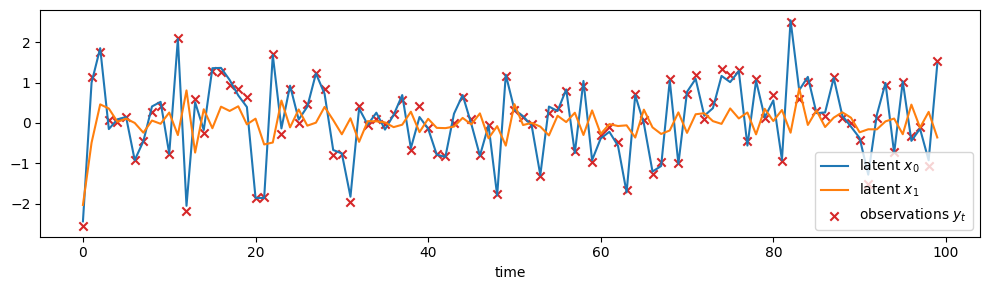

In [6]:
# Extract observations and states for plotting (and for inference below)
print(pred.keys())
obs_values = pred["observations"][0]
states = pred["states"][0]

# Plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(obs_times, states[:, 0], label="latent $x_0$", color='C0')
ax.plot(obs_times, states[:, 1], label="latent $x_1$", color='C1')
ax.scatter(obs_times, obs_values, label="observations $y_t$", color='C3', marker='x')
ax.legend()
ax.set_xlabel("time")
plt.tight_layout()
plt.show()

## 2.6 Inference: conditioning on data

To do inference given data, we first construct our data as a `Context` object:

In [7]:
observed_context = Context(observations=Trajectory(times=obs_times, values=obs_values),
                            controls=Trajectory(times=obs_times, values=ctrl_values))


We create a `data_conditioned_model` that wraps the base model with:

1. **`with Condition(observed_context)`** - this tells us what data to condition the model on.
3. **`with DiscreteTimeSimulator():`** — this tells us HOW to condition the model on the data. Here, it is the same conditioner setup as for simulation, but now the context provides *values* for the observations, so those sites become observed (not sampled).



In [8]:
def data_conditioned_model():
    with DiscreteTimeSimulator():
        with Condition(observed_context):
            return lti_model()


The result is a standard NumPyro model: we can run **NUTS**, **SVI**, or any other NumPyro inference on it.

In [9]:
from numpyro.infer import MCMC, NUTS

nuts_kernel = NUTS(data_conditioned_model)
mcmc = MCMC(nuts_kernel, num_warmup=100, num_samples=100)
mcmc.run(jr.PRNGKey(1))
posterior_sv = mcmc.get_samples()
print("Posterior rho mean:", float(jnp.mean(posterior_sv["rho"])))
print("True rho:", rho_true)

# What did we infer? The Simulator unrolled the model, so we explicitly sampled latent states:
print(posterior_sv.keys())

sample: 100%|██████████| 200/200 [00:00<00:00, 349.69it/s, 31 steps of size 1.89e-01. acc. prob=0.89]


Posterior rho mean: 0.34190234541893005
True rho: 0.3
dict_keys(['observations', 'rho', 'states', 'times', 'x_0', 'x_Traced<int32[]>with<DynamicJaxprTrace>'])


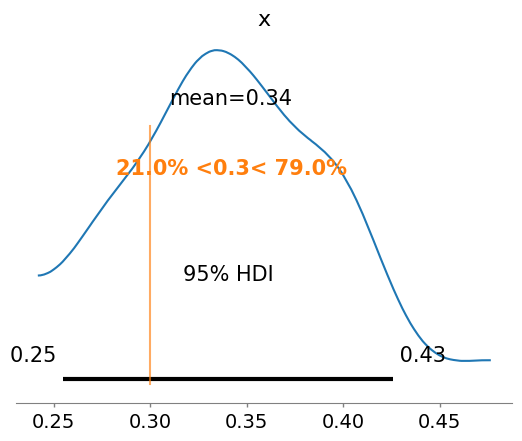

In [10]:
# use arviz to plot the posterior distribution for rho
import arviz as az
az.plot_posterior(posterior_sv["rho"], hdi_prob=0.95,
                  ref_val=rho_true)
plt.show()


### What the Simulator did: unrolling

Using the **Simulator** effectively *unrolled* the model: instead of a single `dsx.sample("f", dynamics)` call, the dynamics were expanded into explicit sample sites `states` ($x_0, x_1, \ldots, x_T$) and `observations` ($y_0, y_1, \ldots, y_T$). Pedagogically, the Simulator does something like:

```python
# Conceptual unrolling (what the Simulator does internally):
x_0 = numpyro.sample("x_0", initial_condition)
y_0 = numpyro.sample("y_0", observation_model(x_0, u_0, t_0))
x_1 = numpyro.sample("x_1", state_evolution(x_0, u_0, t_0, t_1))
y_1 = numpyro.sample("y_1", observation_model(x_1, u_1, t_1))
# ... and so on for each time step
```

So MCMC was inferring **both** the parameter $\rho$ and the full latent state trajectory $x_{0:T}$ explicitly. The printed sample keys include `rho` and `states`, ….

Next, we compare MCMC's state recovery vs the true states generated in the original simulation of the model. Note that this is considered a `smoothing` distribution, but we did not run a typical smoothing algorithm (we will do this in later tutorials, and see its advantages)...here, though, we simply ran MCMC directly on the joint inference problem over `rho` and `states`

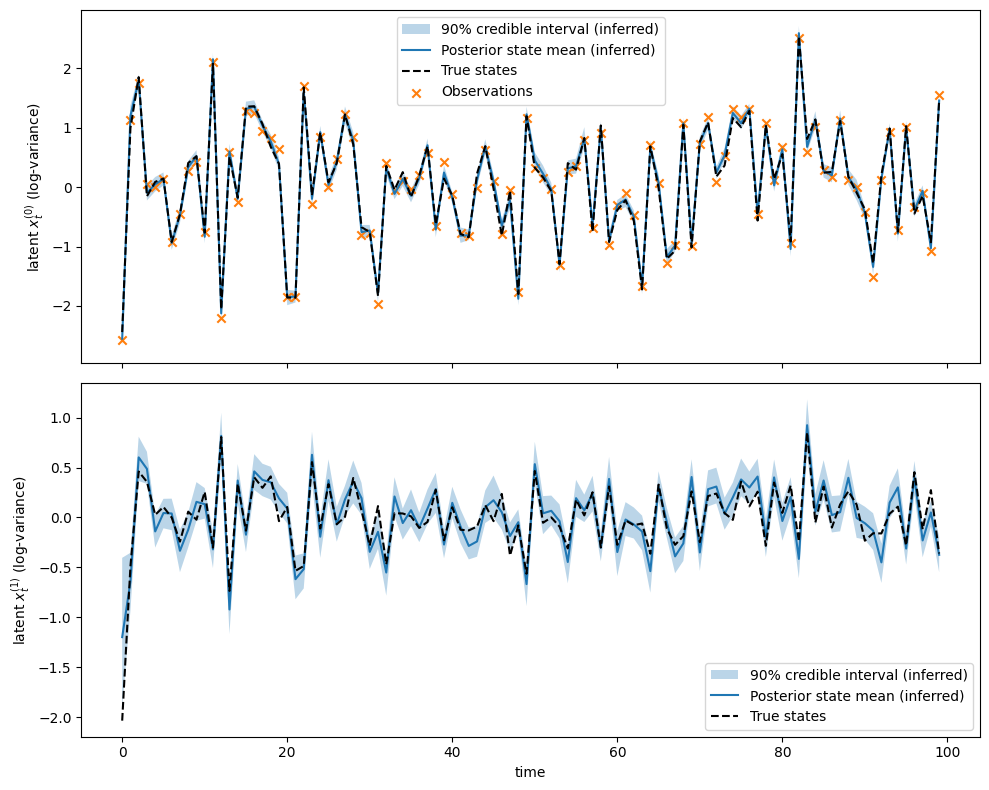

In [11]:
# Plot inferred states vs true states: posterior distribution over the latent trajectory,
# with a subplot for each latent variable/state dimension

inferred_states = jnp.asarray(posterior_sv["states"])  # (n_samples, T+1, state_dim)
if inferred_states.ndim == 2:
    # Promote to (n_samples, T+1, 1) for uniformity
    inferred_states = inferred_states[..., None]
n_samples, T1, state_dim = inferred_states.shape

true_states = jnp.asarray(states)
if true_states.ndim == 1:
    # (T+1,) -> (T+1, 1)
    true_states = true_states[:, None]
elif true_states.ndim == 2 and true_states.shape[1] != state_dim:
    true_states = true_states.T  # if shapes are mismatched: (state_dim, T+1) -> (T+1, state_dim)

posterior_mean = inferred_states.mean(axis=0)  # (T+1, state_dim)
q05 = jnp.percentile(inferred_states, 5, axis=0)  # (T+1, state_dim)
q95 = jnp.percentile(inferred_states, 95, axis=0)  # (T+1, state_dim)

fig, axes = plt.subplots(state_dim, 1, figsize=(10, 4 * state_dim), sharex=True)
if state_dim == 1:
    axes = [axes]  # make iterable

for i, ax in enumerate(axes):
    ax.fill_between(obs_times, q05[:, i], q95[:, i], alpha=0.3, label="90% credible interval (inferred)")
    ax.plot(obs_times, posterior_mean[:, i], label="Posterior state mean (inferred)", color="C0")
    ax.plot(obs_times, true_states[:, i], label="True states", color="black", linestyle="--")
    # Plot observations only on first subplot (if obs_values is appropriate size)
    if i == 0 and "obs_values" in locals():
        if hasattr(obs_values, "shape") and (obs_values.ndim == 1 or obs_values.shape[1] == 1):
            ax.scatter(obs_times, obs_values, label="Observations", color="C1", marker='x')
        elif obs_values.ndim == 2 and obs_values.shape[1] > i:
            ax.scatter(obs_times, obs_values[:, i], label="Observations", color="C1", marker='x')
    ax.set_ylabel(f"latent $x^{{({i})}}_t$ (log-variance)")
    ax.legend()
axes[-1].set_xlabel("time")
plt.tight_layout()
plt.show()

### Lead-in to Part 3

Sometimes it is too costly or difficult to infer these latent states explicitly via MCMC/SVI—especially for long time series or complex / noisy dynamics. That is where **filtering** comes to the rescue: it allows MCMC/SVI to focus only on **parameters**, while the filter **marginalizes** (averages) over the possible latent states and computes $p(y_{1:T} \mid \theta)$. In Part 3 we will see how to do that.

**Next:** [Part 3 — Filtering and the marginal log-likelihood](../03_filtering_mll.ipynb)